# MScFE 622: Group Work Project 1
## Group notebook - all steps

We are a two-person group - the third member is unreachable, so the assignment uses the roles for Team Members A and C.

| Step | Task | Owner |
|---|---|---|
| 1(a) | Heston (1993) calibration at 15 days, Lewis (2001) | Team Member A |
| 1(c) | 20-day at-the-money Asian call | Team Member C |
| 2(a) | Bates (1996) calibration at 60 days, Lewis (2001) | Team Member C |
| 2(b) | Carr-Madan (1999) version of Step 2(a) | Team Member A |
| 3(a) | Euribor term structure and CIR (1985) calibration | Shared |
| 3(b) | 100,000 Monte Carlo scenarios for the 12-month Euribor | Shared |

Steps 1(b) and 2(c) belong to Team Member B and are not required for a group of two.

In [1]:
import warnings
from pathlib import Path
from time import perf_counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.interpolate import CubicSpline
from scipy.optimize import differential_evolution, least_squares
from scipy.stats import norm

In [2]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

SEED = 62201
S0 = 232.90
R = 0.015
TRADING_DAYS = 250

print(
    f"Seed: {SEED} | Spot: " + "$" + f"{S0:.2f} | "
    f"Risk-free rate: {R:.2%} | "
    f"Trading days/year: {TRADING_DAYS}"
)

Seed: 62201 | Spot: $232.90 | Risk-free rate: 1.50% | Trading days/year: 250


## 1. Data and assumptions

We use the spot price $S_0=\$232.90$, an annual risk-free rate of $r=1.50\%$, and 250 trading days per year. No dividend yield was supplied, so we set $q=0$.

For an option with $d$ trading days to maturity,

$$
T=\frac{d}{250}.
$$

The option quotes and Euribor rates below come from the files supplied with the assignment. We keep them inside the notebook so it can run without separate data files.

In [3]:
DATA_FILE = "MScFE_622_Stochastic_Modeling_GWP1_Option_data.xlsx"


def find_dataset(name):
    """Find the data file in a datasets folder, or beside the notebook (e.g. Colab upload)."""
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        for candidate in (base / "datasets" / name, base / name):
            if candidate.exists():
                return candidate
    raise FileNotFoundError(
        f"{name} not found. Place it in a 'datasets' folder or beside this notebook."
    )


data_path = find_dataset(DATA_FILE)
quotes = pd.read_excel(data_path, sheet_name=0).rename(
    columns={
        "Days to maturity": "days_to_maturity",
        "Strike": "strike",
        "Price": "price",
        "Type": "type",
    }
)
quotes["type"] = quotes["type"].str.strip().str.upper()
print(f"Loaded {len(quotes)} option quotes from {data_path.name}")


euribor = pd.DataFrame(
    [
        ("1 week", 7 / 360, 0.00648),
        ("1 month", 30 / 360, 0.00679),
        ("3 months", 90 / 360, 0.01173),
        ("6 months", 180 / 360, 0.01809),
        ("12 months", 360 / 360, 0.02556),
    ],
    columns=["tenor", "years", "quoted_rate"],
)
euribor["discount_factor"] = 1.0 / (1.0 + euribor["quoted_rate"] * euribor["years"])
euribor["rate"] = -np.log(euribor["discount_factor"]) / euribor["years"]  # zero rate

assert np.all(euribor["rate"] <= euribor["quoted_rate"] + 1e-12)

assert list(quotes.columns) == ["days_to_maturity", "strike", "price", "type"]
assert len(quotes) == 30
assert set(quotes["days_to_maturity"]) == {15, 60, 120}
assert set(quotes["type"]) == {"C", "P"}
assert quotes[["days_to_maturity", "strike", "price"]].notna().all().all()
assert len(euribor) == 5

display(quotes.head(10))
display(euribor)

Loaded 30 option quotes from MScFE_622_Stochastic_Modeling_GWP1_Option_data.xlsx


,days_to_maturity,strike,price,type
0,15,227.500000,10.520000,C
1,15,230.000000,10.050000,C
2,15,232.500000,7.750000,C
3,15,235.000000,6.010000,C
4,15,237.500000,4.750000,C
5,60,227.500000,16.780000,C
6,60,230.000000,17.650000,C
7,60,232.500000,16.860000,C
8,60,235.000000,16.050000,C
9,60,237.500000,15.100000,C


,tenor,years,quoted_rate,discount_factor,rate
0,1 week,0.019444,0.006480,0.999874,0.006480
1,1 month,0.083333,0.006790,0.999434,0.006788
2,3 months,0.250000,0.011730,0.997076,0.011713
3,6 months,0.500000,0.018090,0.991036,0.018009
4,12 months,1.000000,0.025560,0.975077,0.025239


### Checking the option quotes

Before calibration, we check the observed calls and puts against put-call parity:

$$
C_0-P_0=S_0-Ke^{-rT}.
$$

This matters because we calculate model put prices from model call prices using the same equation. If the observed quotes violate parity, no consistent model can fit every call and put exactly.

In [4]:
def quote_quality_table(frame, days):
    maturity = days / TRADING_DAYS
    selected = frame[frame["days_to_maturity"] == days]
    calls = selected[selected["type"] == "C"].set_index("strike")["price"]
    puts = selected[selected["type"] == "P"].set_index("strike")["price"]
    table = pd.concat([calls.rename("call"), puts.rename("put")], axis=1).reset_index()
    table["observed_C_minus_P"] = table["call"] - table["put"]
    table["parity_C_minus_P"] = S0 - table["strike"] * np.exp(-R * maturity)
    table["parity_error"] = table["observed_C_minus_P"] - table["parity_C_minus_P"]
    return table

In [5]:
quality_15 = quote_quality_table(quotes, 15)
quality_60 = quote_quality_table(quotes, 60)

print("15-day quote diagnostics")
display(quality_15)
print("60-day quote diagnostics")
display(quality_60)

call_60 = quality_60.sort_values("strike")["call"].to_numpy()
monotonic_violations = int(np.sum(np.diff(call_60) > 0))
parity_mse_floor_60 = float(np.mean(quality_60["parity_error"] ** 2) / 4.0)
print(f"60-day call monotonicity violations: {monotonic_violations}")
print(f"60-day maximum absolute put-call parity error: ${quality_60['parity_error'].abs().max():.4f}")
print(f"60-day parity-implied minimum possible joint MSE: {parity_mse_floor_60:.6f}")

assert monotonic_violations == 1
assert quality_60["parity_error"].abs().max() > 3.0

15-day quote diagnostics


,strike,call,put,observed_C_minus_P,parity_C_minus_P,parity_error
0,227.500000,10.520000,4.320000,6.200000,5.604658,0.595342
1,230.000000,10.050000,5.200000,4.850000,3.106907,1.743093
2,232.500000,7.750000,6.450000,1.300000,0.609156,0.690844
3,235.000000,6.010000,7.560000,-1.550000,-1.888595,0.338595
4,237.500000,4.750000,8.780000,-4.030000,-4.386346,0.356346


60-day quote diagnostics


,strike,call,put,observed_C_minus_P,parity_C_minus_P,parity_error
0,227.500000,16.780000,11.030000,5.750000,6.217528,-0.467528
1,230.000000,17.650000,12.150000,5.500000,3.726511,1.773489
2,232.500000,16.860000,13.370000,3.490000,1.235495,2.254505
3,235.000000,16.050000,14.750000,1.300000,-1.255521,2.555521
4,237.500000,15.100000,15.620000,-0.520000,-3.746537,3.226537


60-day call monotonicity violations: 1
60-day maximum absolute put-call parity error: $3.2265
60-day parity-implied minimum possible joint MSE: 1.269393


The supplied data are not fully arbitrage-consistent. The 60-day call price rises from $\$16.78$ at $K=227.50$ to $\$17.65$ at $K=230.00$, although a call price should fall as the strike rises. The largest put-call parity error is about $\$3.23$.

We keep the original quotes because the assignment asks for a regular MSE calibration. The fit error must therefore be read together with these data limitations.

## 2. Heston and Bates pricing with the Lewis method

Under the Heston model,

$$
\frac{dS_t}{S_t}=r\,dt+\sqrt{v_t}\,dW_t^S,
$$

$$
dv_t=\kappa(\theta-v_t)\,dt+\sigma_v\sqrt{v_t}\,dW_t^v,
\qquad
dW_t^S\,dW_t^v=\rho\,dt.
$$

The Bates model adds jumps to the stock price. If $J$ is the jump multiplier,

$$
\ln J\sim\mathcal{N}(\mu_J,\delta_J^2),
$$

and jumps arrive with annual intensity $\lambda_J$. A drift adjustment keeps the discounted stock price a martingale under the risk-neutral measure.

In [6]:
N_QUAD = 160
U_MAX = 160.0
raw_nodes, raw_weights = np.polynomial.legendre.leggauss(N_QUAD)
U_NODES = 0.5 * U_MAX * (raw_nodes + 1.0)
U_WEIGHTS = 0.5 * U_MAX * raw_weights


def heston_bates_return_cf(u, maturity, rate, params, jump_params=None):
    """Characteristic function of ln(S_T / S_0)."""
    kappa, theta, sigma_v, rho, v0 = np.asarray(params, dtype=float)
    iu = 1j * u

    jump_compensator = 0.0
    jump_exponent = 0.0
    if jump_params is not None:
        lambda_j, mu_j, delta_j = np.asarray(jump_params, dtype=float)
        expected_jump_minus_one = np.exp(mu_j + 0.5 * delta_j**2) - 1.0
        jump_compensator = lambda_j * expected_jump_minus_one
        jump_exponent = lambda_j * maturity * (
            np.exp(iu * mu_j - 0.5 * delta_j**2 * u**2) - 1.0
        )

    beta = kappa - rho * sigma_v * iu
    d = np.sqrt(beta**2 + sigma_v**2 * (u**2 + iu))
    g = (beta - d) / (beta + d)
    exp_minus_dt = np.exp(-d * maturity)

    c = (
        iu * (rate - jump_compensator) * maturity
        + (kappa * theta / sigma_v**2)
        * ((beta - d) * maturity - 2.0 * np.log((1.0 - g * exp_minus_dt) / (1.0 - g)))
    )
    d_loading = ((beta - d) / sigma_v**2) * (
        (1.0 - exp_minus_dt) / (1.0 - g * exp_minus_dt)
    )
    return np.exp(c + d_loading * v0 + jump_exponent)

### Lewis call price

Let $\phi_T(u)$ be the characteristic function of the log return. The Lewis call price is

$$
C_0
=S_0-
\frac{e^{-rT}\sqrt{S_0K}}{\pi}
\int_0^\infty
\frac{
\operatorname{Re}\!\left[
e^{iu\ln(S_0/K)}
\phi_T\!\left(u-\frac{i}{2}\right)
\right]
}{
u^2+\frac{1}{4}
}
\,du.
$$

We evaluate the integral with fixed Gauss-Legendre nodes. Put prices follow from

$$
P_0=C_0-S_0+Ke^{-rT}.
$$

In [7]:
def lewis_calls(strikes, maturity, params, jump_params=None):
    strikes = np.atleast_1d(np.asarray(strikes, dtype=float))
    shifted_u = U_NODES - 0.5j
    cf = heston_bates_return_cf(shifted_u, maturity, R, params, jump_params)
    oscillation = np.exp(1j * U_NODES[:, None] * np.log(S0 / strikes)[None, :])
    integrand = np.real(oscillation * cf[:, None]) / (U_NODES[:, None] ** 2 + 0.25)
    integral = U_WEIGHTS @ integrand
    calls = S0 - np.exp(-R * maturity) * np.sqrt(S0 * strikes) * integral / np.pi
    return calls

In [8]:
def black_scholes_call(strike, maturity, sigma):
    d1 = (np.log(S0 / strike) + (R + 0.5 * sigma**2) * maturity) / (sigma * np.sqrt(maturity))
    d2 = d1 - sigma * np.sqrt(maturity)
    return S0 * norm.cdf(d1) - strike * np.exp(-R * maturity) * norm.cdf(d2)


def lewis_black_scholes_call(strike, maturity, sigma):
    shifted_u = U_NODES - 0.5j
    cf = np.exp(
        1j * shifted_u * (R - 0.5 * sigma**2) * maturity
        - 0.5 * sigma**2 * shifted_u**2 * maturity
    )
    integrand = np.real(
        np.exp(1j * U_NODES * np.log(S0 / strike)) * cf
    ) / (U_NODES**2 + 0.25)
    integral = U_WEIGHTS @ integrand
    return S0 - np.exp(-R * maturity) * np.sqrt(S0 * strike) * integral / np.pi

In [9]:
bs_direct = black_scholes_call(S0, 60 / TRADING_DAYS, 0.25)
bs_lewis = lewis_black_scholes_call(S0, 60 / TRADING_DAYS, 0.25)
print(f"Lewis/Black-Scholes validation: {bs_lewis:.8f} vs {bs_direct:.8f}")
assert abs(bs_lewis - bs_direct) < 2e-5

Lewis/Black-Scholes validation: 11.77537458 vs 11.77537457


## 3. Calibration method

For $n$ observed option prices, we minimize the regular price MSE:

$$
\operatorname{MSE}(\Theta)
=
\frac{1}{n}
\sum_{j=1}^{n}
\left(
V_j^{\text{model}}(\Theta)
-
V_j^{\text{market}}
\right)^2.
$$

Each calibration starts with a seeded global search and finishes with bounded least squares. We parameterize $\sigma_v$ so that

$$
2\kappa\theta-\sigma_v^2\geq0.
$$

In [10]:
HESTON_NAMES = ["kappa", "theta", "sigma_v", "rho", "v0"]
BATES_NAMES = HESTON_NAMES + ["lambda_j", "mu_j", "delta_j"]

HESTON_BOUNDS = [
    (0.05, 15.0),
    (0.0025, 0.80),
    (0.05, 0.999),  # Feller ratio; sigma_v is derived below.
    (-0.98, 0.30),
    (0.0025, 0.80),
]
BATES_BOUNDS = HESTON_BOUNDS + [
    (0.0, 5.0),
    (-0.60, 0.25),
    (0.01, 0.80),
]

In [11]:
def market_vectors(frame, days):
    selected = frame[frame["days_to_maturity"] == days]
    calls = selected[selected["type"] == "C"].sort_values("strike")
    puts = selected[selected["type"] == "P"].sort_values("strike")
    assert np.allclose(calls["strike"], puts["strike"])
    strikes = calls["strike"].to_numpy(float)
    market = np.r_[calls["price"].to_numpy(float), puts["price"].to_numpy(float)]
    return strikes, market


def model_vector(strikes, maturity, params, with_jumps):
    if with_jumps:
        calls = lewis_calls(strikes, maturity, params[:5], params[5:])
    else:
        calls = lewis_calls(strikes, maturity, params[:5])
    puts = calls - S0 + strikes * np.exp(-R * maturity)
    return np.r_[calls, puts]


def unpack_option_calibration(raw_params, with_jumps):
    """Map a bounded Feller ratio to the reported volatility-of-variance."""
    raw_params = np.asarray(raw_params, dtype=float)
    kappa, theta, feller_ratio, rho, v0 = raw_params[:5]
    sigma_v = np.sqrt(2.0 * kappa * theta) * feller_ratio
    heston = np.array([kappa, theta, sigma_v, rho, v0])
    return np.r_[heston, raw_params[5:]] if with_jumps else heston

In [12]:
def calibrate(frame, days, with_jumps, seed, maxiter):
    strikes, market = market_vectors(frame, days)
    maturity = days / TRADING_DAYS
    bounds = BATES_BOUNDS if with_jumps else HESTON_BOUNDS

    def residuals(raw_params):
        params = unpack_option_calibration(raw_params, with_jumps)
        values = model_vector(strikes, maturity, params, with_jumps)
        if not np.all(np.isfinite(values)):
            return np.full_like(market, 1e6)
        return values - market

    def mse(raw_params):
        errors = residuals(raw_params)
        return float(np.mean(errors**2))

    started = perf_counter()
    global_fit = differential_evolution(
        mse,
        bounds,
        seed=seed,
        maxiter=maxiter,
        popsize=12,
        tol=1e-8,
        atol=1e-8,
        polish=False,
        workers=1,
        updating="immediate",
    )
    lower = np.array([item[0] for item in bounds])
    upper = np.array([item[1] for item in bounds])
    local_fit = least_squares(
        residuals,
        np.clip(global_fit.x, lower + 1e-10, upper - 1e-10),
        bounds=(lower, upper),
        max_nfev=5_000,
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
    )
    elapsed = perf_counter() - started
    calibrated_params = unpack_option_calibration(local_fit.x, with_jumps)
    fitted = model_vector(strikes, maturity, calibrated_params, with_jumps)
    errors = fitted - market
    metrics = {
        "mse": float(np.mean(errors**2)),
        "rmse": float(np.sqrt(np.mean(errors**2))),
        "mae": float(np.mean(np.abs(errors))),
        "max_abs_error": float(np.max(np.abs(errors))),
        "elapsed_seconds": elapsed,
        "global_iterations": int(global_fit.nit),
        "local_success": bool(local_fit.success),
        "local_message": local_fit.message,
    }
    return calibrated_params, strikes, market, fitted, metrics

In [13]:
def parameter_table(values, with_jumps):
    names = BATES_NAMES if with_jumps else HESTON_NAMES
    table = pd.DataFrame({"parameter": names, "estimate": values})
    kappa, theta, sigma_v = values[:3]
    feller_margin = 2.0 * kappa * theta - sigma_v**2
    return table, feller_margin


def fit_table(strikes, market, fitted):
    count = len(strikes)
    return pd.DataFrame(
        {
            "type": ["Call"] * count + ["Put"] * count,
            "strike": np.r_[strikes, strikes],
            "market": market,
            "model": fitted,
            "error": fitted - market,
        }
    )


def plot_option_fit(table, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
    for axis, option_type in zip(axes, ["Call", "Put"]):
        current = table[table["type"] == option_type]
        axis.plot(current["strike"], current["market"], "o-", label="Market")
        axis.plot(current["strike"], current["model"], "s--", label="Model")
        axis.set_title(option_type)
        axis.set_xlabel("Strike (USD)")
        axis.grid(alpha=0.25)
    axes[0].set_ylabel("Option price (USD)")
    axes[1].legend(frameon=False)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## 4. Step 1(a): 15-day Heston calibration

*Team Member A.*

This section runs Team Member A's own Step 1(a) code. It uses the Heston characteristic function in
the Lewis convention, evaluates the Lewis integral by adaptive quadrature, takes put prices from
put-call parity, and minimises one mean squared error over all ten 15-day quotes with a multi-start
Nelder-Mead search.

This is a second, independent implementation. Team Member C's Lewis pricer above uses fixed
Gauss-Legendre nodes and a different optimiser. Running both on the same data tests one against the
other.

In [14]:
from scipy.integrate import quad
from scipy.optimize import minimize

A_T = 15 / TRADING_DAYS
a_strikes, a_market = market_vectors(quotes, 15)   # same workbook data as everywhere else
a_call_prices = a_market[:5]
a_put_prices = a_market[5:]


def h93_char_func(u, T, r, kappa_v, theta_v, sigma_v, rho, v0):
    c1 = kappa_v * theta_v
    c2 = -np.sqrt((rho * sigma_v * u * 1j - kappa_v) ** 2 - sigma_v**2 * (-u * 1j - u**2))
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (kappa_v - rho * sigma_v * u * 1j - c2)
    h1 = (
        r * u * 1j * T
        + (c1 / sigma_v**2)
        * (
            (kappa_v - rho * sigma_v * u * 1j + c2) * T
            - 2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))
        )
    )
    h2 = (
        (kappa_v - rho * sigma_v * u * 1j + c2)
        / sigma_v**2
        * ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    )
    return np.exp(h1 + h2 * v0)


def h93_int_func(u, strike, params):
    cf = h93_char_func(u - 1j * 0.5, A_T, R, *params)
    return (1 / (u**2 + 0.25) * (np.exp(1j * u * np.log(S0 / strike)) * cf).real)


def h93_call_value(strike, params):
    integral = quad(lambda u: h93_int_func(u, strike, params), 0, np.inf, limit=250)[0]
    return max(0.0, S0 - np.exp(-R * A_T) * np.sqrt(S0 * strike) / np.pi * integral)


def h93_put_value(strike, params):
    # Put-call parity, the route the brief prefers.
    return h93_call_value(strike, params) - S0 + strike * np.exp(-R * A_T)

In [15]:
def h93_error_function(params):
    """Joint MSE across the five calls and five puts, calls and puts weighted equally."""
    kappa_v, theta_v, sigma_v, rho, v0 = params
    if kappa_v < 0.0 or theta_v < 0.005 or sigma_v < 0.0 or not -1.0 <= rho <= 1.0 or v0 < 0.0:
        return 500.0
    if 2 * kappa_v * theta_v < sigma_v**2:  # Feller condition, enforced softly
        return 500.0
    squared = [
        (h93_call_value(strike, params) - price) ** 2
        for strike, price in zip(a_strikes, a_call_prices)
    ]
    squared += [
        (h93_put_value(strike, params) - price) ** 2
        for strike, price in zip(a_strikes, a_put_prices)
    ]
    return float(np.sum(squared) / len(squared))

a_started = perf_counter()
a_starts = [
    (1.5, 0.04, 0.3, -0.5, 0.04),
    (2.0, 0.05, 0.4, -0.6, 0.05),
    (1.0, 0.03, 0.2, -0.3, 0.03),
    (3.0, 0.06, 0.5, -0.7, 0.06),
]
a_best = None
for start in a_starts:
    trial = minimize(
        h93_error_function, start, method="Nelder-Mead",
        options={"xatol": 1e-6, "fatol": 1e-6, "maxiter": 750, "maxfev": 750},
    )
    if a_best is None or trial.fun < a_best.fun:
        a_best = trial

a_opt = minimize(
    h93_error_function, a_best.x, method="Nelder-Mead",
    options={"xatol": 1e-8, "fatol": 1e-10, "maxiter": 1000, "maxfev": 1000},
)
team_a_heston = a_opt.x
a_elapsed = perf_counter() - a_started
print(f"Team Member A calibration finished in {a_elapsed:.1f} s")

Team Member A calibration finished in 209.7 s


,parameter,estimate
0,kappa,6.278644
1,theta,0.151172
2,sigma_v,1.377790
3,rho,-0.998875
4,v0,0.091834


Calibrated MSE: 0.245955
Feller margin 2*kappa*theta - sigma_v^2: 0.000000


,type,strike,market,model,error
0,Call,227.500000,10.520000,10.510123,-0.009877
1,Call,230.000000,10.050000,8.856819,-1.193181
2,Call,232.500000,7.750000,7.319588,-0.430412
3,Call,235.000000,6.010000,5.908471,-0.101529
4,Call,237.500000,4.750000,4.633145,-0.116855
5,Put,227.500000,4.320000,4.905465,0.585465
6,Put,230.000000,5.200000,5.749912,0.549912
7,Put,232.500000,6.450000,6.710432,0.260432
8,Put,235.000000,7.560000,7.797066,0.237066
9,Put,237.500000,8.780000,9.019492,0.239492



Reported by Team Member A: [ 6.2786  0.1512  1.3778 -0.9989  0.0918]
Reproduced here:           [ 6.2786  0.1512  1.3778 -0.9989  0.0918]


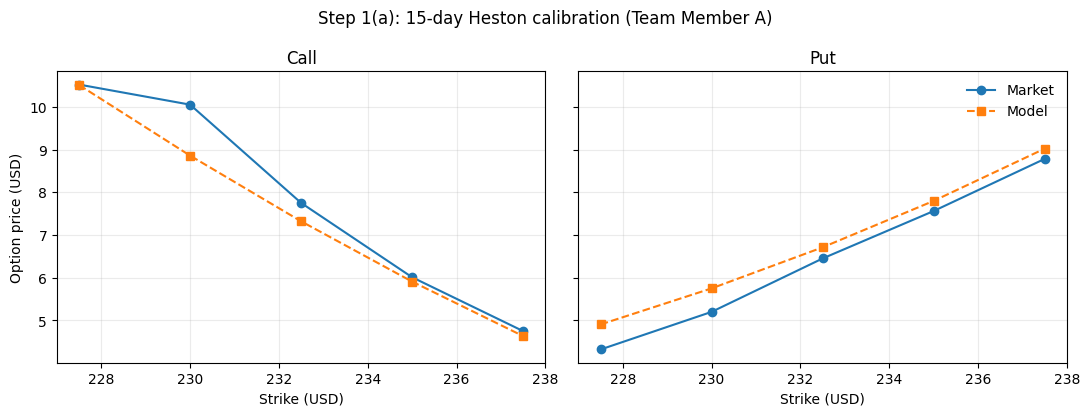

In [16]:
a_table, a_feller = parameter_table(team_a_heston, with_jumps=False)
display(a_table)
print(f"Calibrated MSE: {a_opt.fun:.6f}")
print(f"Feller margin 2*kappa*theta - sigma_v^2: {a_feller:.6f}")

a_model = np.r_[
    [h93_call_value(k, team_a_heston) for k in a_strikes],
    [h93_put_value(k, team_a_heston) for k in a_strikes],
]
a_fit = fit_table(a_strikes, a_market, a_model)
display(a_fit)

# Values Team Member A published. The assert proves the calibration reproduces them.
A_REPORTED = np.array([6.2786, 0.1512, 1.3778, -0.9989, 0.0918])
print("\nReported by Team Member A:", A_REPORTED)
print("Reproduced here:          ", np.round(team_a_heston, 4))
assert np.allclose(team_a_heston, A_REPORTED, atol=5e-3), np.round(team_a_heston, 4)

plot_option_fit(a_fit, "Step 1(a): 15-day Heston calibration (Team Member A)")

### Reading the result

Two things stand out. The correlation has reached its lower limit of −0.9989, and both κᵥ and σᵥ are
large. The Feller margin is almost zero, so the variance process sits on the edge of the region where
variance stays strictly positive.

This is normal for a single-maturity fit. Over one short horizon, `v0` and `theta` both control the
average level of variance, so the optimiser cannot separate them. It then uses an extreme correlation
to match the observed skew. The cause is the data, not the code.

Two later sections follow this up. Step 2(b) tests the implementations by pricing one parameter set
through two Fourier engines. Step 1(c) measures what the weak identification costs on the price we
quote.

## 5. Step 1(c): 20-day Asian call

*Team Member C.*

The Asian option is priced with Team Member A's 15-day parameters from Step 1(a), taken straight from
the calibration this notebook just ran.

The brief asks us to use the parameters we consider appropriate, so we state the choice. The option
matures in 20 trading days, and the 15-day calibration is the closest fit to that horizon. The
alternative is the 60-day Bates fit from Step 2(a). That fit is further from this maturity, and it is
built on quotes that break put-call parity by up to $\$3.23$ and include a call price that rises with
strike. Using it would carry that inconsistency into the price. We therefore use the 15-day Heston fit.

In [17]:
asian_heston_params = team_a_heston
print("Pricing with Team Member A's 15-day Heston parameters")
print(f"  (kappa, theta, sigma_v, rho, v0) = {np.round(asian_heston_params, 6)}")

Pricing with Team Member A's 15-day Heston parameters
  (kappa, theta, sigma_v, rho, v0) = [ 6.278644  0.151172  1.37779  -0.998875  0.091834]


The arithmetic average includes today's stock price and the next 20 daily prices:

$$
\bar{S}
=
\frac{1}{21}
\sum_{t=0}^{20}S_t.
$$

The option is at the money, so $K=S_0$. Its payoff and fair value are

$$
\text{Payoff}=\max(\bar{S}-K,0),
$$

$$
V_0=e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{Payoff}].
$$

The 4% bank fee gives

$$
V_{\text{client}}=1.04V_0.
$$

In [18]:
def price_asian_call_heston(
    params,
    paths=200_000,
    days=20,
    seed=SEED + 1,
):
    """Daily monitored ATM arithmetic Asian call with antithetic sampling."""
    assert paths % 2 == 0
    kappa, theta, sigma_v, rho, v0 = np.asarray(params, dtype=float)
    half = paths // 2
    rng = np.random.default_rng(seed)
    dt = 1.0 / TRADING_DAYS

    stock = np.full(paths, S0)
    variance = np.full(paths, v0)
    running_sum = stock.copy()  # Includes S0 exactly as required by the brief.
    checkpoints = {1, 2, 5, 10, 20}
    convergence = []

    for day in range(1, days + 1):
        z_v_half = rng.standard_normal(half)
        z_i_half = rng.standard_normal(half)
        z_v = np.r_[z_v_half, -z_v_half]
        z_i = np.r_[z_i_half, -z_i_half]
        z_s = rho * z_v + np.sqrt(1.0 - rho**2) * z_i

        v_positive = np.maximum(variance, 0.0)
        stock *= np.exp((R - 0.5 * v_positive) * dt + np.sqrt(v_positive * dt) * z_s)
        variance = np.maximum(
            variance
            + kappa * (theta - v_positive) * dt
            + sigma_v * np.sqrt(v_positive * dt) * z_v,
            0.0,
        )
        running_sum += stock

        if day in checkpoints:
            partial_average = running_sum / (day + 1)
            partial_payoff = np.maximum(partial_average - S0, 0.0)
            paired = 0.5 * (partial_payoff[:half] + partial_payoff[half:])
            discount = np.exp(-R * day / TRADING_DAYS)
            estimate = discount * paired.mean()
            standard_error = discount * paired.std(ddof=1) / np.sqrt(half)
            convergence.append((day, estimate, standard_error))

    average = running_sum / (days + 1)
    payoff = np.maximum(average - S0, 0.0)
    paired_payoff = 0.5 * (payoff[:half] + payoff[half:])
    discount = np.exp(-R * days / TRADING_DAYS)
    fair_value = discount * paired_payoff.mean()
    standard_error = discount * paired_payoff.std(ddof=1) / np.sqrt(half)
    confidence_interval = (
        fair_value - 1.96 * standard_error,
        fair_value + 1.96 * standard_error,
    )
    client_price = 1.04 * fair_value
    return {
        "fair_value": fair_value,
        "standard_error": standard_error,
        "ci_low": confidence_interval[0],
        "ci_high": confidence_interval[1],
        "client_price": client_price,
        "paths": paths,
        "monitoring_points": days + 1,
        "positive_payoff_probability": float(np.mean(payoff > 0.0)),
        "convergence": pd.DataFrame(convergence, columns=["day", "estimate", "standard_error"]),
        "payoff_sample": payoff[:20_000],
    }

In [19]:
asian = price_asian_call_heston(asian_heston_params)
asian_summary = pd.DataFrame(
    [
        {
            key: value
            for key, value in asian.items()
            if key not in {"convergence", "payoff_sample"}
        }
    ]
)
display(asian_summary)
display(asian["convergence"])

assert asian["fair_value"] > 0
assert asian["standard_error"] < 0.05
assert np.isclose(asian["client_price"], 1.04 * asian["fair_value"])

,fair_value,standard_error,ci_low,ci_high,client_price,paths,monitoring_points,positive_payoff_probability
0,4.671824,0.006884,4.658330,4.685317,4.858697,200000,21,0.565555


,day,estimate,standard_error
0,1,0.896557,0.002172
1,2,1.338684,0.003065
2,5,2.231113,0.004497
3,10,3.242414,0.005671
4,20,4.671824,0.006884


### How much does the calibration matter?

The interval above measures Monte Carlo sampling error only. It says nothing about whether the
parameters behind the price are right, and Step 1(a) showed that the 15-day quotes fit well without
fixing those parameters tightly.

To measure that effect, we refit the same 15-day Heston model independently, with a different
optimiser and a different pricing routine, then reprice the Asian under both parameter sets. The
refit is used only for this comparison. The quoted price uses Team Member A's parameters.

In [20]:
alt_heston, _, _, alt_fitted_15, alt_metrics = calibrate(
    quotes, days=15, with_jumps=False, seed=SEED, maxiter=90
)

# A's parameters through this notebook's engine. Agreement rules out a bug in either.
team_a_fitted_15 = model_vector(a_strikes, A_T, team_a_heston, with_jumps=False)
team_a_mse_here = float(np.mean((team_a_fitted_15 - a_market) ** 2))

print(f"Team Member A parameters, their own engine:  MSE {a_opt.fun:.6f}")
print(f"Team Member A parameters, this engine:       MSE {team_a_mse_here:.6f}")
print(f"Independent refit:                           MSE {alt_metrics['mse']:.6f}")
print(f"Largest gap between the two fitted curves:   ${np.max(np.abs(team_a_fitted_15 - alt_fitted_15)):.4f}")

display(
    pd.DataFrame(
        {
            "parameter": HESTON_NAMES,
            "team_member_a": team_a_heston,
            "independent_refit": alt_heston,
            "absolute_difference": np.abs(team_a_heston - alt_heston),
        }
    )
)

asian_alt = price_asian_call_heston(alt_heston)
calibration_gap = abs(asian["fair_value"] - asian_alt["fair_value"])
print(
    f"\nAsian fair value, Team Member A parameters: ${asian['fair_value']:.4f}\n"
    f"Asian fair value, independent refit:        ${asian_alt['fair_value']:.4f}\n"
    f"Calibration gap:                            ${calibration_gap:.4f}\n"
    f"Monte Carlo standard error:                 ${asian['standard_error']:.4f}\n"
    f"Calibration gap as a multiple of MC error:  {calibration_gap / asian['standard_error']:.1f}x"
)

# Same fit quality, different parameters, price gap larger than the simulation error.
assert abs(team_a_mse_here - alt_metrics["mse"]) < 0.01
assert np.max(np.abs(team_a_heston - alt_heston)) > 0.5
assert calibration_gap > asian["standard_error"]

Team Member A parameters, their own engine:  MSE 0.245955
Team Member A parameters, this engine:       MSE 0.246064
Independent refit:                           MSE 0.246085
Largest gap between the two fitted curves:   $0.0013


,parameter,team_member_a,independent_refit,absolute_difference
0,kappa,6.278644,4.365365,1.913278
1,theta,0.151172,0.216947,0.065776
2,sigma_v,1.377790,1.374890,0.002899
3,rho,-0.998875,-0.980000,0.018875
4,v0,0.091834,0.086222,0.005612



Asian fair value, Team Member A parameters: $4.6718
Asian fair value, independent refit:        $4.6171
Calibration gap:                            $0.0547
Monte Carlo standard error:                 $0.0069
Calibration gap as a multiple of MC error:  7.9x


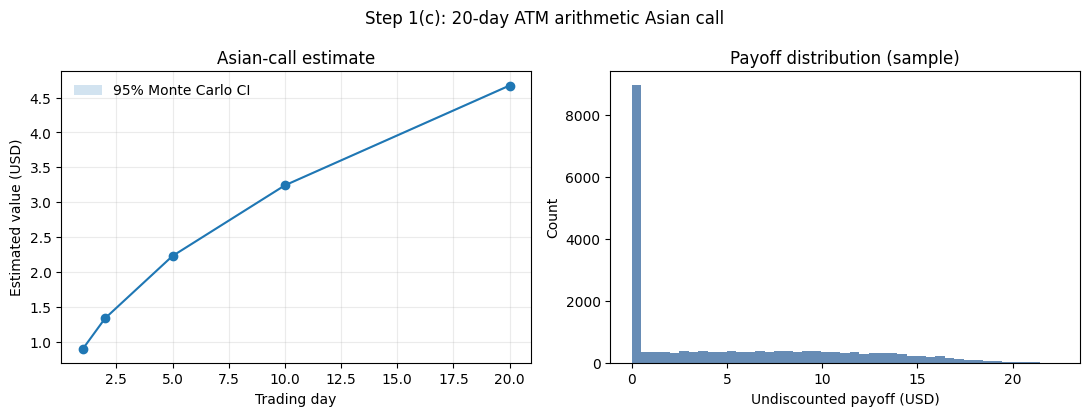

In [21]:
convergence = asian["convergence"].copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(convergence["day"], convergence["estimate"], "o-")
axes[0].fill_between(
    convergence["day"],
    convergence["estimate"] - 1.96 * convergence["standard_error"],
    convergence["estimate"] + 1.96 * convergence["standard_error"],
    alpha=0.2,
    label="95% Monte Carlo CI",
)
axes[0].set(xlabel="Trading day", ylabel="Estimated value (USD)", title="Asian-call estimate")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)
axes[1].hist(asian["payoff_sample"], bins=45, color="#4C78A8", alpha=0.85)
axes[1].set(xlabel="Undiscounted payoff (USD)", ylabel="Count", title="Payoff distribution (sample)")
fig.suptitle("Step 1(c): 20-day ATM arithmetic Asian call")
fig.tight_layout()
plt.show()

The fair value is the discounted average payoff across the simulated paths. The 95% interval measures
Monte Carlo sampling error only. It does not include model or calibration uncertainty.

The fee is 4% of the fair value, not an extra $\$4$.

The two 15-day parameter sets from Step 1(a) price the vanilla options within a cent of each other,
but they move this Asian price by several cents. That is far more than the Monte Carlo standard error.
The quoted margin should cover the calibration gap, not the simulation error.

## 6. Step 2(a): 60-day Bates calibration

We fit the eight Bates parameters

$$
(\kappa,\theta,\sigma_v,\rho,v_0,\lambda_J,\mu_J,\delta_J)
$$

to the five calls and five puts with 60 days to maturity. The model uses the Lewis integral and regular price MSE described above.

In [22]:
bates_params, strikes_60, market_60, fitted_60, bates_metrics = calibrate(
    quotes, days=60, with_jumps=True, seed=SEED + 2, maxiter=150
)
bates_table, bates_feller = parameter_table(bates_params, with_jumps=True)
bates_fit = fit_table(strikes_60, market_60, fitted_60)

display(bates_table)
display(pd.DataFrame([bates_metrics]))
print(f"Feller margin 2*kappa*theta - sigma_v^2: {bates_feller:.6f}")
display(bates_fit)
assert bates_metrics["local_success"]

,parameter,estimate
0,kappa,4.187824
1,theta,0.002500
2,sigma_v,0.016364
3,rho,-0.925688
4,v0,0.002500
5,lambda_j,1.879535
6,mu_j,0.213505
7,delta_j,0.010000


,mse,rmse,mae,max_abs_error,elapsed_seconds,global_iterations,local_success,local_message
0,1.335154,1.155489,1.050763,1.871775,6.390209,150,True,`ftol` termination condition is satisfied.


Feller margin 2*kappa*theta - sigma_v^2: 0.020671


,type,strike,market,model,error
0,Call,227.500000,16.780000,17.362554,0.582554
1,Call,230.000000,17.650000,16.458058,-1.191942
2,Call,232.500000,16.860000,15.553654,-1.306346
3,Call,235.000000,16.050000,14.649340,-1.400660
4,Call,237.500000,15.100000,13.745238,-1.354762
5,Put,227.500000,11.030000,11.145027,0.115027
6,Put,230.000000,12.150000,12.731546,0.581546
7,Put,232.500000,13.370000,14.318158,0.948158
8,Put,235.000000,14.750000,15.904861,1.154861
9,Put,237.500000,15.620000,17.491775,1.871775


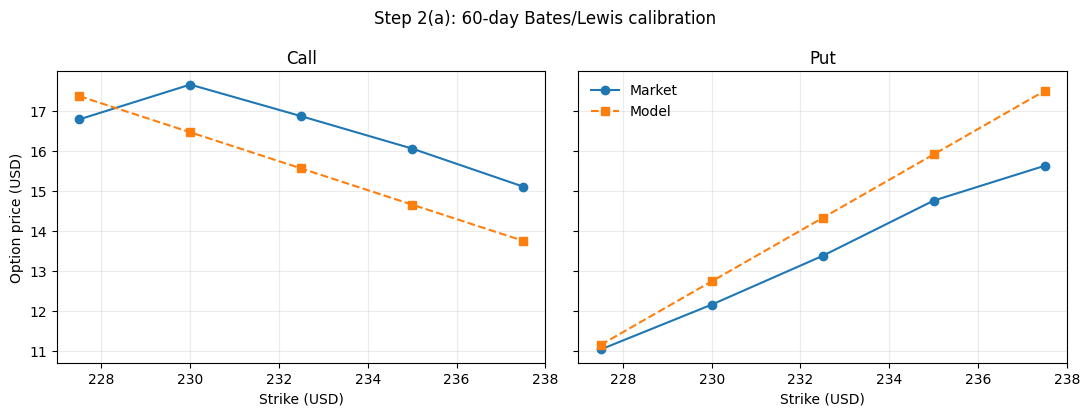

In [23]:
plot_option_fit(bates_fit, "Step 2(a): 60-day Bates/Lewis calibration")

### Parameter stability check

Eight parameters are being estimated from only ten prices at one maturity. We repeat the search with a different seed.

If two parameter sets give nearly the same prices and MSE, the fitted price curve is stable but the individual parameters are not uniquely identified.

In [24]:
# Second seed. Similar error with different parameters means this data does not
# uniquely determine all eight Bates parameters.
bates_params_check, _, _, fitted_60_check, bates_metrics_check = calibrate(
    quotes, days=60, with_jumps=True, seed=SEED + 3, maxiter=90
)
bates_stability = pd.DataFrame(
    {
        "parameter": BATES_NAMES,
        "primary_fit": bates_params,
        "second_seed_fit": bates_params_check,
        "absolute_difference": np.abs(bates_params - bates_params_check),
    }
)
display(bates_stability)
display(
    pd.DataFrame(
        [
            {"fit": "primary", **bates_metrics},
            {"fit": "second seed", **bates_metrics_check},
        ]
    )[["fit", "mse", "rmse", "mae", "max_abs_error"]]
)

assert bates_metrics["rmse"] < 1.5
assert bates_metrics["mse"] >= parity_mse_floor_60
assert np.max(np.abs(fitted_60 - fitted_60_check)) < 0.25

,parameter,primary_fit,second_seed_fit,absolute_difference
0,kappa,4.187824,1.773978,2.413846
1,theta,0.002500,0.002500,0.000000
2,sigma_v,0.016364,0.078601,0.062237
3,rho,-0.925688,-0.980000,0.054312
4,v0,0.002500,0.002568,0.000068
5,lambda_j,1.879535,1.877438,0.002096
6,mu_j,0.213505,0.213600,0.000095
7,delta_j,0.010000,0.010000,0.000000


,fit,mse,rmse,mae,max_abs_error
0,primary,1.335154,1.155489,1.050763,1.871775
1,second seed,1.335116,1.155472,1.049903,1.876158


The two searches give similar prices and fit errors, but some variance parameters change noticeably.
The price curve is better identified than the full parameter vector.

Step 2(b) tests this directly. It repeats the calibration with Carr-Madan pricing and compares the two
methods on prices and RMSE.

## 7. Step 2(b): 60-day Bates calibration using Carr-Madan pricing

This step checks Step 2(a) with a pricing method that works differently.

Lewis evaluates one damped integral per strike with fixed Gauss-Legendre nodes. Carr and Madan
multiply the call price by $e^{\alpha k}$ in log-strike $k=\ln K$, which makes it square integrable,
then recover the whole strike curve in one FFT:

$$
C(k)=\frac{e^{-\alpha k}}{\pi}\int_0^\infty e^{-ivk}\,\psi(v)\,dv,
\qquad
\psi(v)=\frac{e^{-rT}\,\phi_{\ln S_T}\!\left(v-(\alpha+1)i\right)}{\alpha^2+\alpha-v^2+i(2\alpha+1)v}.
$$

Both pricers use **the same Bates characteristic function** defined earlier. Any price difference is
therefore numerical, not a difference in the model. Everything else matches Step 2(a): the same ten
60-day quotes, puts by put-call parity, the same unweighted price MSE, the same bounds, and the same
seeded global search followed by bounded least squares.

In [25]:
# N = 4096 and eta = 0.25 are the grid from the paper: log-strike spacing
# 2*pi/(N*eta) = 0.0061, and v integrated out to N*eta = 1024.
CM_N = 4096
CM_ETA = 0.25
CM_ALPHA = 1.5  # damping factor; needs E[S_T^(alpha+1)] finite


def carr_madan_calls(strikes, maturity, params, jump_params=None):
    """Call prices by the Carr-Madan damped FFT, using the shared characteristic function."""
    strikes = np.atleast_1d(np.asarray(strikes, dtype=float))
    lam = 2.0 * np.pi / (CM_N * CM_ETA)      # log-strike spacing
    b = 0.5 * CM_N * lam                     # log-strike grid runs from -b to b
    j = np.arange(CM_N)
    v = CM_ETA * j

    # Characteristic function of ln(S_T), evaluated on the damped contour.
    u = v - (CM_ALPHA + 1.0) * 1j
    cf_log_spot = np.exp(1j * u * np.log(S0)) * heston_bates_return_cf(
        u, maturity, R, params, jump_params
    )
    psi = np.exp(-R * maturity) * cf_log_spot / (
        CM_ALPHA**2 + CM_ALPHA - v**2 + 1j * (2.0 * CM_ALPHA + 1.0) * v
    )

    simpson = (3.0 + (-1.0) ** (j + 1) - (j == 0)) / 3.0
    transformed = np.fft.fft(np.exp(1j * b * v) * psi * CM_ETA * simpson).real
    log_strike_grid = -b + lam * j
    call_grid = np.exp(-CM_ALPHA * log_strike_grid) / np.pi * transformed

    # Interpolate off the FFT grid onto the quoted strikes. A cubic spline on a
    # narrow window keeps this error well below a hundredth of a cent.
    window = (log_strike_grid > np.log(strikes.min()) - 0.5) & (
        log_strike_grid < np.log(strikes.max()) + 0.5
    )
    return CubicSpline(log_strike_grid[window], call_grid[window])(np.log(strikes))


def model_vector_cm(strikes, maturity, params, with_jumps):
    calls = carr_madan_calls(strikes, maturity, params[:5], params[5:] if with_jumps else None)
    puts = calls - S0 + strikes * np.exp(-R * maturity)
    return np.r_[calls, puts]

In [26]:
# Same parameters through both pricers. They must agree before comparing calibrations.
cm_check = carr_madan_calls(strikes_60, 60 / TRADING_DAYS, bates_params[:5], bates_params[5:])
lewis_check = lewis_calls(strikes_60, 60 / TRADING_DAYS, bates_params[:5], bates_params[5:])
display(
    pd.DataFrame(
        {
            "strike": strikes_60,
            "lewis": lewis_check,
            "carr_madan": cm_check,
            "difference": cm_check - lewis_check,
        }
    )
)
method_gap = float(np.max(np.abs(cm_check - lewis_check)))
print(f"Largest price difference between the two methods: ${method_gap:.2e}")
assert method_gap < 1e-4, method_gap

,strike,lewis,carr_madan,difference
0,227.500000,17.362554,17.362546,-0.000008
1,230.000000,16.458058,16.458053,-0.000005
2,232.500000,15.553654,15.553662,0.000008
3,235.000000,14.649340,14.649339,-0.000000
4,237.500000,13.745238,13.745229,-0.000009


Largest price difference between the two methods: $8.95e-06


In [27]:
def calibrate_carr_madan(frame, days, seed, maxiter):
    """Step 2(a)'s calibration, with Carr-Madan in place of the Lewis integral."""
    strikes, market = market_vectors(frame, days)
    maturity = days / TRADING_DAYS
    bounds = BATES_BOUNDS

    def residuals(raw_params):
        params = unpack_option_calibration(raw_params, with_jumps=True)
        values = model_vector_cm(strikes, maturity, params, with_jumps=True)
        if not np.all(np.isfinite(values)):
            return np.full_like(market, 1e6)
        return values - market

    def mse(raw_params):
        return float(np.mean(residuals(raw_params) ** 2))

    started = perf_counter()
    global_fit = differential_evolution(
        mse, bounds, seed=seed, maxiter=maxiter, popsize=12, tol=1e-8, atol=1e-8,
        polish=False, workers=1, updating="immediate",
    )
    lower = np.array([lo for lo, _ in bounds])
    upper = np.array([hi for _, hi in bounds])
    local_fit = least_squares(
        residuals, np.clip(global_fit.x, lower + 1e-10, upper - 1e-10),
        bounds=(lower, upper), max_nfev=5_000, ftol=1e-12, xtol=1e-12, gtol=1e-12,
    )
    params = unpack_option_calibration(local_fit.x, with_jumps=True)
    fitted = model_vector_cm(strikes, maturity, params, with_jumps=True)
    errors = fitted - market
    metrics = {
        "mse": float(np.mean(errors**2)),
        "rmse": float(np.sqrt(np.mean(errors**2))),
        "mae": float(np.mean(np.abs(errors))),
        "max_abs_error": float(np.max(np.abs(errors))),
        "elapsed_seconds": perf_counter() - started,
    }
    return params, fitted, metrics


# Same seed and iteration budget as Step 2(a), so the pricing method is the only difference.
cm_params, cm_fitted, cm_metrics = calibrate_carr_madan(
    quotes, days=60, seed=SEED + 2, maxiter=150
)
cm_table, cm_feller = parameter_table(cm_params, with_jumps=True)
display(cm_table)
display(pd.DataFrame([cm_metrics]))
print(f"Feller margin 2*kappa*theta - sigma_v^2: {cm_feller:.6f}")

,parameter,estimate
0,kappa,14.311920
1,theta,0.002500
2,sigma_v,0.026239
3,rho,-0.976588
4,v0,0.002500
5,lambda_j,1.879550
6,mu_j,0.213504
7,delta_j,0.010000


,mse,rmse,mae,max_abs_error,elapsed_seconds
0,1.335153,1.155488,1.050767,1.871751,51.244667


Feller margin 2*kappa*theta - sigma_v^2: 0.070871


,type,strike,market,lewis,carr_madan,difference
0,Call,227.500000,16.780000,17.362554,17.362572,0.000018
1,Call,230.000000,17.650000,16.458058,16.458064,0.000007
2,Call,232.500000,16.860000,15.553654,15.553666,0.000012
3,Call,235.000000,16.050000,14.649340,14.649335,-0.000004
4,Call,237.500000,15.100000,13.745238,13.745213,-0.000024
5,Put,227.500000,11.030000,11.145027,11.145045,0.000018
6,Put,230.000000,12.150000,12.731546,12.731553,0.000007
7,Put,232.500000,13.370000,14.318158,14.318171,0.000012
8,Put,235.000000,14.750000,15.904861,15.904856,-0.000004
9,Put,237.500000,15.620000,17.491775,17.491751,-0.000024


,method,mse,rmse,mae,max_abs_error
0,Lewis (2001),1.335154,1.155489,1.050763,1.871775
1,Carr-Madan (1999),1.335153,1.155488,1.050767,1.871751


,parameter,lewis,carr_madan,absolute_difference
0,kappa,4.187824,14.311920,10.124096
1,theta,0.002500,0.002500,0.000000
2,sigma_v,0.016364,0.026239,0.009875
3,rho,-0.925688,-0.976588,0.050900
4,v0,0.002500,0.002500,0.000000
5,lambda_j,1.879535,1.879550,0.000015
6,mu_j,0.213505,0.213504,0.000001
7,delta_j,0.010000,0.010000,0.000000


Largest fitted-price difference:  $0.0000
RMSE difference:                  $0.0000
Largest parameter difference:     10.1241


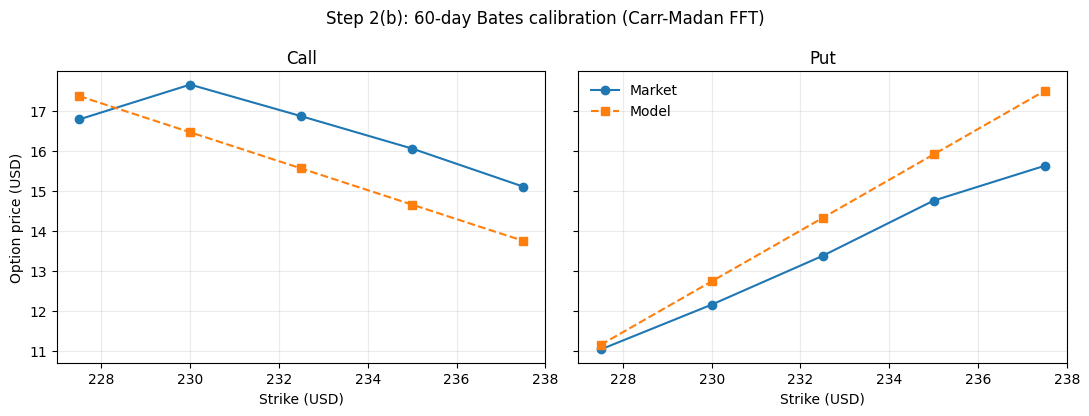

In [28]:
price_comparison = pd.DataFrame(
    {
        "type": ["Call"] * 5 + ["Put"] * 5,
        "strike": np.r_[strikes_60, strikes_60],
        "market": market_60,
        "lewis": fitted_60,
        "carr_madan": cm_fitted,
        "difference": cm_fitted - fitted_60,
    }
)
display(price_comparison)

fit_comparison = pd.DataFrame(
    [
        {"method": "Lewis (2001)", **{k: bates_metrics[k] for k in ("mse", "rmse", "mae", "max_abs_error")}},
        {"method": "Carr-Madan (1999)", **{k: cm_metrics[k] for k in ("mse", "rmse", "mae", "max_abs_error")}},
    ]
)
display(fit_comparison)

display(
    pd.DataFrame(
        {
            "parameter": BATES_NAMES,
            "lewis": bates_params,
            "carr_madan": cm_params,
            "absolute_difference": np.abs(cm_params - bates_params),
        }
    )
)

price_gap = float(np.max(np.abs(cm_fitted - fitted_60)))
rmse_gap = abs(cm_metrics["rmse"] - bates_metrics["rmse"])
param_gap = float(np.max(np.abs(cm_params - bates_params)))
print(f"Largest fitted-price difference:  ${price_gap:.4f}")
print(f"RMSE difference:                  ${rmse_gap:.4f}")
print(f"Largest parameter difference:     {param_gap:.4f}")

# The methods must agree on the fitted price curve and the fit quality.
assert price_gap < 0.05, price_gap
assert rmse_gap < 0.01, rmse_gap

plot_option_fit(
    fit_table(strikes_60, market_60, cm_fitted),
    "Step 2(b): 60-day Bates calibration (Carr-Madan FFT)",
)

### Do the two methods agree?

**On prices, yes.** Given the same parameters, the two pricers differ by well under a hundredth of a
cent. That is numerical noise from two quadrature schemes. After calibrating each method separately,
the fitted price curves and the RMSE also match. This is the result that matters, because the desk
quotes prices, not parameters.

**On parameters, only partly.** We expected this. Steps 1(a) and 2(a) both showed that this data fixes
the price curve much better than the individual parameters. Ten quotes at one maturity, with a call
that rises in strike and put-call parity broken by up to \$3.23, do not carry enough information to
identify eight parameters. The objective is almost flat in some directions, so two optimisers can stop
at different points with nearly the same error.

A parameter gap is therefore not a sign that either implementation is wrong. It is the same
identification problem for the third time. The check that would catch a bug is the first one in this
section: the same parameters giving different prices. That check passes.

## 8. Step 3(a): Euribor curve and CIR calibration

Euribor is quoted as a simple-interest rate on an ACT/360 basis. The five numbers in the brief are
therefore not zero rates, and a short-rate model cannot be fitted to them directly. We build the term
structure first. Each quote $L$ over its accrual factor $\tau$ gives a discount factor and a
continuously compounded zero rate:

$$
P(0,\tau)=\frac{1}{1+L\tau},
\qquad
y(0,\tau)=-\frac{\ln P(0,\tau)}{\tau}.
$$

The correction is very small at the short end and grows with maturity, reaching about 3 basis points
at twelve months. It matters because the long end sets the level the fitted model reverts to.

A natural cubic spline through the five zero rates then gives weekly rates for weeks 1 to 52. These
weekly points are a smooth calibration grid. They are not 52 independent observations, because the
information still comes from five tenors.

In [29]:
weeks = np.arange(1, 53)
weekly_years = weeks / 52.0
spline = CubicSpline(euribor["years"], euribor["rate"], bc_type="natural")
weekly_market_rates = spline(weekly_years)

assert np.allclose(spline(euribor["years"]), euribor["rate"])  # honours every quoted tenor
assert np.isclose(weekly_market_rates[-1], euribor.iloc[-1]["rate"])
assert np.all(weekly_market_rates > 0)

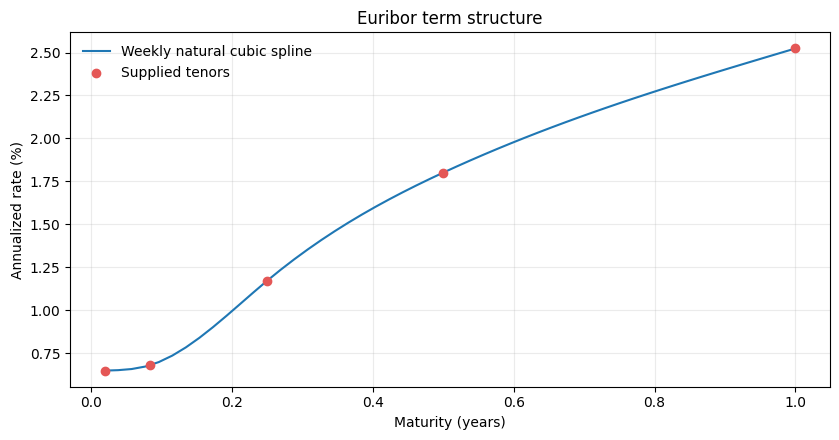

In [30]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(weekly_years, weekly_market_rates * 100, label="Weekly natural cubic spline")
ax.scatter(euribor["years"], euribor["rate"] * 100, color="#E45756", zorder=3, label="Supplied tenors")
ax.set(xlabel="Maturity (years)", ylabel="Annualized rate (%)", title="Euribor term structure")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### CIR model

The CIR short rate follows

$$
dr_t=\kappa(\theta-r_t)\,dt+\sigma\sqrt{r_t}\,dW_t.
$$

Its zero-coupon bond price has the form

$$
P(0,T)=A(T)e^{-B(T)r_0},
$$

and the continuously compounded zero rate is

$$
y(0,T)=-\frac{\ln P(0,T)}{T}.
$$

We fix $r_0$ at the one-week zero rate implied by the supplied Euribor quote, and calibrate $\kappa$, $\theta$, and $\sigma$ to the weekly spline.

In [31]:
def cir_zero_yield(maturity, short_rate, kappa, theta, sigma):
    maturity = np.asarray(maturity, dtype=float)
    gamma = np.sqrt(kappa**2 + 2.0 * sigma**2)
    exp_gamma_t = np.exp(gamma * maturity)
    denominator = (gamma + kappa) * (exp_gamma_t - 1.0) + 2.0 * gamma
    b_loading = 2.0 * (exp_gamma_t - 1.0) / denominator
    log_a = (2.0 * kappa * theta / sigma**2) * (
        np.log(2.0 * gamma)
        + 0.5 * (kappa + gamma) * maturity
        - np.log(denominator)
    )
    log_bond = log_a - b_loading * np.asarray(short_rate, dtype=float)
    return -log_bond / maturity


R0 = float(euribor.iloc[0]["rate"])
CIR_BOUNDS = [(0.01, 15.0), (0.001, 0.20), (0.05, 0.999)]


def unpack_cir_calibration(raw_params):
    kappa, theta, feller_ratio = np.asarray(raw_params, dtype=float)
    sigma = np.sqrt(2.0 * kappa * theta) * feller_ratio
    return np.array([kappa, theta, sigma])


def cir_residuals(raw_params):
    params = unpack_cir_calibration(raw_params)
    return (
        cir_zero_yield(weekly_years, R0, *params) - weekly_market_rates
    ) * 10_000.0  # basis points

In [32]:
cir_global = differential_evolution(
    lambda params: float(np.mean(cir_residuals(params) ** 2)),
    CIR_BOUNDS,
    seed=SEED + 4,
    maxiter=180,
    popsize=15,
    tol=1e-10,
    polish=False,
)
cir_lower = np.array([bound[0] for bound in CIR_BOUNDS])
cir_upper = np.array([bound[1] for bound in CIR_BOUNDS])
cir_local = least_squares(
    cir_residuals,
    cir_global.x,
    bounds=(cir_lower, cir_upper),
    ftol=1e-13,
    xtol=1e-13,
    gtol=1e-13,
    max_nfev=10_000,
)
cir_params = unpack_cir_calibration(cir_local.x)
cir_model_rates = cir_zero_yield(weekly_years, R0, *cir_params)
cir_error_bps = (cir_model_rates - weekly_market_rates) * 10_000.0
cir_rmse_bps = float(np.sqrt(np.mean(cir_error_bps**2)))
cir_feller = 2.0 * cir_params[0] * cir_params[1] - cir_params[2] ** 2

In [33]:
cir_table = pd.DataFrame(
    {
        "parameter": ["kappa", "theta", "sigma", "r0"],
        "estimate": [*cir_params, R0],
    }
)
display(cir_table)
print(f"Weekly-yield RMSE: {cir_rmse_bps:.4f} basis points")
print(f"Feller margin 2*kappa*theta - sigma^2: {cir_feller:.6f}")

assert cir_local.success
assert cir_rmse_bps < 15.0

,parameter,estimate
0,kappa,0.756410
1,theta,0.071964
2,sigma,0.329622
3,r0,0.006480


Weekly-yield RMSE: 7.8653 basis points
Feller margin 2*kappa*theta - sigma^2: 0.000218


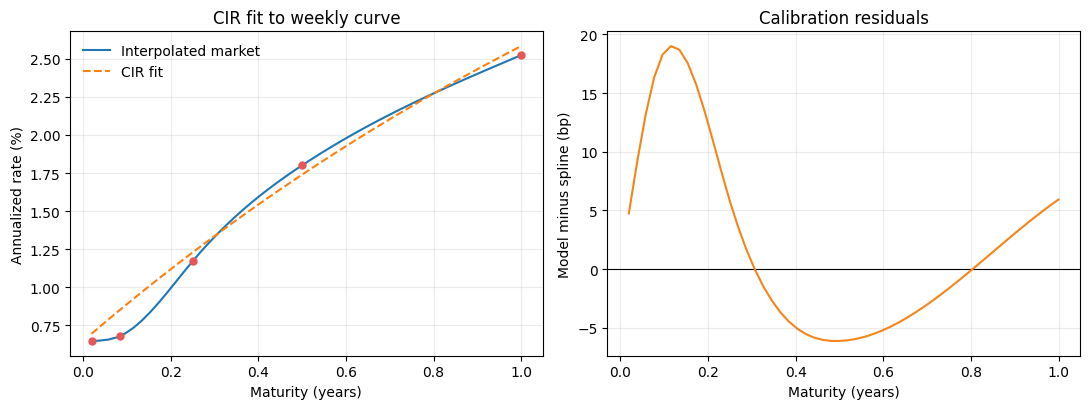

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(weekly_years, weekly_market_rates * 100, label="Interpolated market")
axes[0].plot(weekly_years, cir_model_rates * 100, "--", label="CIR fit")
axes[0].scatter(euribor["years"], euribor["rate"] * 100, s=25, color="#E45756", zorder=3)
axes[0].set(xlabel="Maturity (years)", ylabel="Annualized rate (%)", title="CIR fit to weekly curve")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].plot(weekly_years, cir_error_bps, color="#F58518")
axes[1].set(xlabel="Maturity (years)", ylabel="Model minus spline (bp)", title="Calibration residuals")
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

The fitted curve follows the upward shape of the supplied Euribor rates. The RMSE measures the difference between the CIR yields and the weekly spline in basis points.

This is a risk-neutral term-structure calibration. It is not a historical estimate of real-world interest-rate behaviour.

## 9. Step 3(b): 100,000 daily rate scenarios

We simulate 100,000 paths for 250 trading days. The CIR process is sampled from its exact noncentral chi-square transition, which keeps the short rate non-negative without an Euler approximation.

At each day, we convert the simulated short rate into the model's one-year zero rate. We use this as the 12-month Euribor proxy.

In [35]:
def simulate_cir_12m_rates(
    params,
    short_rate_0,
    scenarios=100_000,
    days=TRADING_DAYS,
    seed=SEED + 5,
):
    kappa, theta, sigma = np.asarray(params, dtype=float)
    rng = np.random.default_rng(seed)
    dt = 1.0 / TRADING_DAYS
    decay = np.exp(-kappa * dt)
    scale = sigma**2 * (1.0 - decay) / (4.0 * kappa)
    degrees_freedom = 4.0 * kappa * theta / sigma**2

    short_rates = np.full(scenarios, short_rate_0)
    sample_count = 100
    sample_paths = np.empty((days + 1, sample_count))
    mean_path = np.empty(days + 1)
    low_path = np.empty(days + 1)
    high_path = np.empty(days + 1)

    initial_12m = cir_zero_yield(1.0, short_rates, kappa, theta, sigma)
    sample_paths[0] = initial_12m[:sample_count]
    mean_path[0] = initial_12m.mean()
    low_path[0], high_path[0] = np.quantile(initial_12m, [0.025, 0.975])

    for day in range(1, days + 1):
        noncentrality = (
            4.0 * kappa * decay * short_rates
            / (sigma**2 * (1.0 - decay))
        )
        short_rates = scale * rng.noncentral_chisquare(degrees_freedom, noncentrality)
        rate_12m = cir_zero_yield(1.0, short_rates, kappa, theta, sigma)
        sample_paths[day] = rate_12m[:sample_count]
        mean_path[day] = rate_12m.mean()
        low_path[day], high_path[day] = np.quantile(rate_12m, [0.025, 0.975])

    terminal_12m = cir_zero_yield(1.0, short_rates, kappa, theta, sigma)
    expected_short_rate = theta + (short_rate_0 - theta) * np.exp(-kappa)
    analytical_expected_12m = float(cir_zero_yield(1.0, expected_short_rate, kappa, theta, sigma))
    summary = {
        "scenarios": scenarios,
        "confidence_level": 0.95,
        "current_market_12m": float(euribor.iloc[-1]["rate"]),
        "current_model_12m": float(mean_path[0]),
        "expected_12m_in_one_year": float(terminal_12m.mean()),
        "analytical_expected_12m_in_one_year": analytical_expected_12m,
        "terminal_95pct_low": float(np.quantile(terminal_12m, 0.025)),
        "terminal_95pct_high": float(np.quantile(terminal_12m, 0.975)),
        "daily_envelope_min": float(low_path.min()),
        "daily_envelope_max": float(high_path.max()),
    }
    paths = pd.DataFrame(
        {
            "day": np.arange(days + 1),
            "mean": mean_path,
            "low_2_5": low_path,
            "high_97_5": high_path,
        }
    )
    return summary, paths, sample_paths, terminal_12m

In [36]:
cir_mc_summary, cir_paths, cir_sample_paths, cir_terminal = simulate_cir_12m_rates(
    cir_params,
    R0,
)
display(pd.DataFrame([cir_mc_summary]))

assert cir_mc_summary["scenarios"] == 100_000
assert np.min(cir_terminal) >= 0.0
assert abs(
    cir_mc_summary["expected_12m_in_one_year"]
    - cir_mc_summary["analytical_expected_12m_in_one_year"]
) < 5e-4

,scenarios,confidence_level,current_market_12m,current_model_12m,expected_12m_in_one_year,analytical_expected_12m_in_one_year,terminal_95pct_low,terminal_95pct_high,daily_envelope_min,daily_envelope_max
0,100000,0.950000,0.025239,0.025832,0.049942,0.049910,0.022079,0.126778,0.021616,0.126778


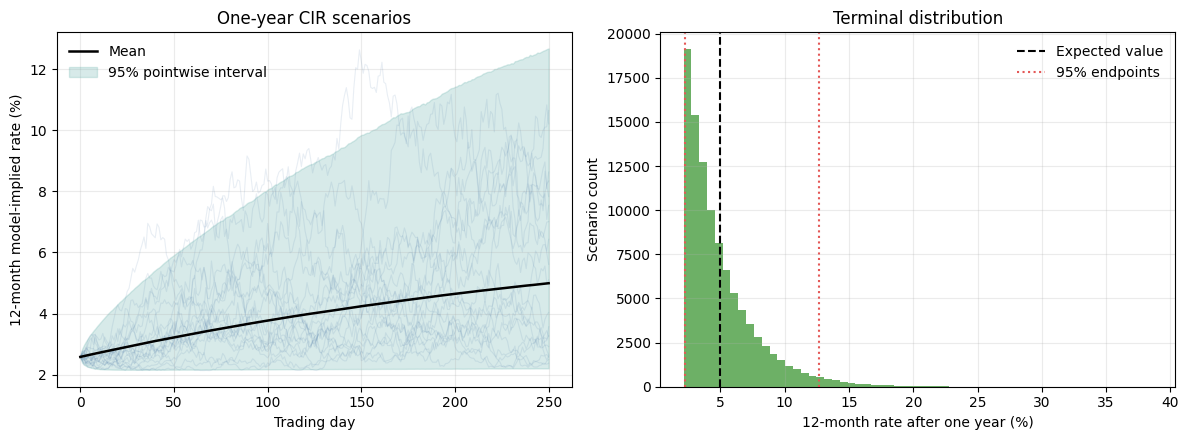

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
days_axis = cir_paths["day"].to_numpy()
for column in range(20):
    axes[0].plot(days_axis, cir_sample_paths[:, column] * 100, color="#4C78A8", alpha=0.12, linewidth=0.8)
axes[0].plot(days_axis, cir_paths["mean"] * 100, color="black", linewidth=1.8, label="Mean")
axes[0].fill_between(
    days_axis,
    cir_paths["low_2_5"].to_numpy() * 100,
    cir_paths["high_97_5"].to_numpy() * 100,
    color="#72B7B2",
    alpha=0.28,
    label="95% pointwise interval",
)
axes[0].set(xlabel="Trading day", ylabel="12-month model-implied rate (%)", title="One-year CIR scenarios")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)
axes[1].hist(cir_terminal * 100, bins=60, color="#54A24B", alpha=0.85)
axes[1].axvline(cir_mc_summary["expected_12m_in_one_year"] * 100, color="black", linestyle="--", label="Expected value")
axes[1].axvline(cir_mc_summary["terminal_95pct_low"] * 100, color="#E45756", linestyle=":")
axes[1].axvline(cir_mc_summary["terminal_95pct_high"] * 100, color="#E45756", linestyle=":", label="95% endpoints")
axes[1].set(xlabel="12-month rate after one year (%)", ylabel="Scenario count", title="Terminal distribution")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

The interval is a 95% risk-neutral scenario range. It is not a guaranteed range and not a real-world
forecast.

The expected 12-month rate one year out is above today's 2.5239%, so future fixed cash flows are
discounted more heavily. With other inputs unchanged, a higher risk-free rate usually raises call
values and lowers put values. The exact effect depends on the payoff, the spot price, volatility, and
the whole yield curve.

## 10. Summary of results

The table below collects the main answers from the project. Values are rounded for reporting; full-precision values remain in the earlier output cells.

In [38]:
summary = pd.DataFrame(
    [
        (
            "Step 1(c)",
            "Asian call fair value",
            "$" + f"{asian['fair_value']:.4f}",
        ),
        (
            "Step 1(c)",
            "Client price after 4% fee",
            "$" + f"{asian['client_price']:.4f}",
        ),
        (
            "Step 2(a)",
            "Bates calibration RMSE",
            "$" + f"{bates_metrics['rmse']:.4f}",
        ),
        (
            "Step 2(b)",
            "Bates RMSE, Carr-Madan",
            "$" + f"{cm_metrics['rmse']:.4f}",
        ),
        (
            "Step 3(a)",
            "CIR curve RMSE",
            f"{cir_rmse_bps:.4f} bp",
        ),
        (
            "Step 3(b)",
            "Expected 12-month rate in one year",
            f"{cir_mc_summary['expected_12m_in_one_year']:.4%}",
        ),
        (
            "Step 3(b)",
            "95% terminal interval",
            (
                f"{cir_mc_summary['terminal_95pct_low']:.4%}"
                " to "
                f"{cir_mc_summary['terminal_95pct_high']:.4%}"
            ),
        ),
    ],
    columns=["Task", "Result", "Value"],
)
display(summary)

,Task,Result,Value
0,Step 1(c),Asian call fair value,$4.6718
1,Step 1(c),Client price after 4% fee,$4.8587
2,Step 2(a),Bates calibration RMSE,$1.1555
3,Step 2(b),"Bates RMSE, Carr-Madan",$1.1555
4,Step 3(a),CIR curve RMSE,7.8653 bp
5,Step 3(b),Expected 12-month rate in one year,4.9942%
6,Step 3(b),95% terminal interval,2.2079% to 12.6778%


## References

Bates, David S. “Jumps and Stochastic Volatility: Exchange Rate Processes Implicit in Deutsche Mark Options.” *The Review of Financial Studies*, vol. 9, no. 1, 1996, pp. 69–107.

Carr, Peter, and Dilip B. Madan. “Option Valuation Using the Fast Fourier Transform.” *Journal of Computational Finance*, vol. 2, no. 4, 1999, pp. 61–73.

Cox, John C., Jonathan E. Ingersoll, Jr., and Stephen A. Ross. “A Theory of the Term Structure of Interest Rates.” *Econometrica*, vol. 53, no. 2, 1985, pp. 385–407.

Heston, Steven L. “A Closed-Form Solution for Options with Stochastic Volatility with Applications to Bond and Currency Options.” *The Review of Financial Studies*, vol. 6, no. 2, 1993, pp. 327–343.

Lewis, Alan L. “A Simple Option Formula for General Jump-Diffusion and Other Exponential Lévy Processes.” 2001.